<a href="https://colab.research.google.com/github/zzzer0-wav/Analysis_Cafe_Sales/blob/main/EDA_cafe_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Analysis Cafe Sales
Cafe Sales - Dirty Data for Cleaning Training

Overview

The Dirty Cafe Sales dataset contains 10,000 rows of synthetic data representing sales transactions in a cafe. This dataset is intentionally "dirty," with missing values, inconsistent data, and errors introduced to provide a realistic scenario for data cleaning and exploratory data analysis (EDA). It can be used to practice cleaning techniques, data wrangling, and feature engineering.
File Information

    File Name: dirty_cafe_sales.csv
    Number of Rows: 10,000
    Number of Columns: 8


| Column Name | Description |
| --- | --- |
| Transaction ID | A unique identifier for each transaction. Always present and unique. |
| Item | The name of the item purchased. May contain missing or invalid values (e.g., "ERROR"). |
| Quantity | The quantity of the item purchased. May contain missing or invalid values. |
| Price Per Unit | The price of a single unit of the item. May contain missing or invalid values. |
| Total Spent | The total amount spent on the transaction. Calculated as Quantity * Price Per Unit. |
| Payment Method | The method of payment used. May contain missing or invalid values (e.g., None, "UNKNOWN"). |
| Location | The location where the transaction occurred. May contain missing or invalid values. |
| Transaction Date | The date of the transaction. May contain missing or incorrect values. |

In [97]:
!pip install numpy pandas matplotlib

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Loading the dataset

In [99]:
url = 'https://raw.githubusercontent.com/zzzer0-wav/Analysis_Cafe_Sales/refs/heads/main/data/dirty_cafe_sales.csv'

In [100]:
df_origin = pd.read_csv(url)

In [101]:
df_origin.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [102]:
df = df_origin.copy()

### Initial diagnosis

In [103]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [105]:
print('Date types (raw):\n')
df.dtypes

Date types (raw):



,0
Transaction ID,object
Item,object
Quantity,object
Price Per Unit,object
Total Spent,object
Payment Method,object
Location,object
Transaction Date,object


Problem:

Numeric columns (Quantity, Price Per Unit, Total Spent)

Date columns (Transaction Date)

In [106]:
print('Missing values:\n')
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100)
missing_report = pd.DataFrame({
    'count': missing,
    '%': missing_pct
})

missing_report[missing_report['count']>0]

Missing values:



,count,%
Item,333,3.33
Quantity,138,1.38
Price Per Unit,179,1.79
Total Spent,173,1.73
Payment Method,2579,25.79
Location,3265,32.65
Transaction Date,159,1.59


In [107]:
print('Unique values:\n')

print('--- Item ---\n')
display(df['Item'].value_counts(dropna=False))

print('--- Payment method ---\n')
display(df['Payment Method'].value_counts(dropna=False))

print('--- Location ---\n')
display(df['Location'].value_counts(dropna=False))

Unique values:

--- Item ---



,count
Item,
Juice,1171
Coffee,1165
Salad,1148
Cake,1139
Sandwich,1131
Smoothie,1096
Cookie,1092
Tea,1089
UNKNOWN,344


--- Payment method ---



,count
Payment Method,
NaN,2579
Digital Wallet,2291
Credit Card,2273
Cash,2258
ERROR,306
UNKNOWN,293


--- Location ---



,count
Location,
NaN,3265
Takeaway,3022
In-store,3017
ERROR,358
UNKNOWN,338


In [108]:
print("Fing lines with 'ERROR' or 'UNKNOWN'\n")
# display(df.isin(['ERROR', 'UNKNOWN']).any())
display(df.isin(['ERROR', 'UNKNOWN']).sum())
mask_error = df.isin(['ERROR', 'UNKNOWN']).any(axis=1).sum()
print(f"Lines with 'ERROR' or 'UNKNOWN': {mask_error.sum()}")


Fing lines with 'ERROR' or 'UNKNOWN'



,0
Transaction ID,0
Item,636
Quantity,341
Price Per Unit,354
Total Spent,329
Payment Method,599
Location,696
Transaction Date,301


Lines with 'ERROR' or 'UNKNOWN': 2845


### Data cleaning

If we dont have copy of dataset - WE HAVE TO MAKE IT HERE

df_origin = origin dataset

df = cope of origin dataset

In [109]:
print('Rename columns:\n')

df.columns = df.columns.str.strip()

df = df.rename(columns={
    'Transaction ID': 'transaction_id',
    'Item': 'item',
    'Quantity': 'quantity',
    'Price Per Unit': 'price_per_unit',
    'Total Spent': 'total_spent',
    'Payment Method': 'payment_method',
    'Location': 'location',
    'Transaction Date': 'transaction_date'
})

print(list(df.columns))

Rename columns:

['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date']


In [110]:
# '   TRansaction Date    '.strip().lower().replace(' ', '_')

In [111]:
# '   TRansaction   Date    '.strip().lower().replace(' ', '_')

In [112]:
# '_'.join('   TRansaction   Date    '.lower().split())

In [113]:
# df.columns.str.lower().str.split()

In [114]:
# 'ERROR' / 'UNKNOWH' -> NaN
df.replace(['ERROR','UNKNOWN', 'error', 'unknown', ''], np.nan, inplace=True)
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [115]:
# Converting numeric columns
for col in ['quantity', 'price_per_unit', 'total_spent']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Converting date
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
# df['transaction_date'] = df_origin['Transaction Date'].copy()

In [116]:
print('Coverting columns:\n')
df.dtypes


Coverting columns:



,0
transaction_id,object
item,object
quantity,float64
price_per_unit,float64
total_spent,float64
payment_method,object
location,object
transaction_date,datetime64[ns]


In [117]:
# Extracting time signatures
df['year'] = df['transaction_date'].dt.year.astype('Int64')
df['month'] = df['transaction_date'].dt.month.astype('Int8')

# df['month_name'] = df['transaction_date'].dt.month_name()
df['month_name'] = df['transaction_date'].dt.strftime('%B')

df['weekday'] = df['transaction_date'].dt.day_name()
df['week'] = df['transaction_date'].dt.isocalendar().week.astype('Int8')


# display(df[['transaction_date', 'year', 'month', 'month_name', 'weekday', 'week']].dtypes)
df[['transaction_date', 'year', 'month', 'month_name', 'weekday', 'week']].head()


,transaction_date,year,month,month_name,weekday,week
0,2023-09-08,2023,9,September,Friday,36
1,2023-05-16,2023,5,May,Tuesday,20
2,2023-07-19,2023,7,July,Wednesday,29
3,2023-04-27,2023,4,April,Thursday,17
4,2023-06-11,2023,6,June,Sunday,23


In [118]:
# Restoring total_spent (quantity * price)

mask_recoverable = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit'].notna()
)

df.loc[mask_recoverable, 'total_spent'] = (
    df.loc[mask_recoverable, 'quantity'] *
    df.loc[mask_recoverable, 'price_per_unit']
)

print(f"Restoring total_spent: {mask_recoverable.sum()} string (quantity * price) ")

Restoring total_spent: 462 string (quantity * price) 


In [119]:
# dict of median prices
price_map = (
    df.dropna(subset=['item', 'price_per_unit'])
    .groupby('item')['price_per_unit']
    .median()
    .to_dict()
)

mask_price = df['price_per_unit'].isna() & df['item'].notna()

df.loc[mask_price, 'price_per_unit'] = df.loc[mask_price, 'item'].map(price_map)

print(f"Restoring price_per_unit: {mask_price.sum()} string (median per item) ")

Restoring price_per_unit: 479 string (median per item) 


In [120]:
# Restoring total_spent (new price - median item)

mask_recoverable2 = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit'].notna()
)

df.loc[mask_recoverable2, 'total_spent'] = (
    df.loc[mask_recoverable2, 'quantity'] *
    df.loc[mask_recoverable2, 'price_per_unit']
)

print(f"Restoring total_spent: {mask_recoverable2.sum()} string (new price - median item) ")

Restoring total_spent: 17 string (new price - median item) 


In [121]:
# fillna item -> mode
mode_item = df['item'].mode()[0]

# df['item'].fillna(mode_item, inplace=True)  # old version
df.fillna({'item': mode_item}, inplace=True)

In [122]:
# payment_method, location -> 'Unknown'
df.fillna(
    {
        'payment_method': 'Unknown',
        'location': 'Unknown'
    },
    inplace=True
)

In [123]:
# Delete transaction_date and quantity where NaT or NaN
before = len(df)

df.dropna(subset=['transaction_date', 'quantity'], inplace=True)

after = len(df)

print(f"Deleted {before - after} rows")

Deleted 914 rows


In [124]:
# Delete duplicates
df.duplicated().sum()  # 0
df.drop_duplicates(inplace=True)

In [125]:
(df.quantity <= 0).sum()  # 0
(df.price_per_unit <= 0).sum()  # 0
(df.total_spent <= 0).sum()  # 0

np.int64(0)

In [126]:
(df['total_spent'].isna() & df['price_per_unit'].isna()).sum()

np.int64(3)

In [127]:
(df['total_spent'].isna() | df['price_per_unit'].isna()).sum()

np.int64(48)

In [128]:
#Restoring price_per_unit (total_spent / quantity)
mask_recoverable3 = (
    df['price_per_unit'].isna() &
    df['total_spent'].notna() &
    df['quantity'].notna()
)

df.loc[mask_recoverable3, 'price_per_unit'] = df.loc[mask_recoverable3, 'total_spent'] / df.loc[mask_recoverable3, 'quantity']
# mask_recoverable.sum()

print(f"Restoring price_per_unit: {mask_recoverable3.sum()} (total_spent / quantity)")

Restoring price_per_unit: 45 (total_spent / quantity)


In [129]:
# Delete rows with NaN
df.dropna(subset=['total_spent'], inplace=True)

print(f"Delete rows with NaN (df['total_spent'].isna() & df['price_per_unit'].isna())")


Delete rows with NaN (df['total_spent'].isna() & df['price_per_unit'].isna())


In [130]:
df.isna().sum().sum()

np.int64(0)

In [131]:
# Check quantity * price_per_unit = total_spent
mask_total_spent = (df.quantity * df.price_per_unit != df.total_spent)
print(f"Uncorrect rows total_spent: {mask_total_spent.sum()}")

Uncorrect rows total_spent: 0


In [132]:
# Text fields are standartized (Title Case)
for col in ['item', 'payment_method',	'location']:
  df[col] = df[col].str.strip().str.title()

print("Text fields are standartized (Title Case)")

Text fields are standartized (Title Case)


In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9083 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    9083 non-null   object        
 1   item              9083 non-null   object        
 2   quantity          9083 non-null   float64       
 3   price_per_unit    9083 non-null   float64       
 4   total_spent       9083 non-null   float64       
 5   payment_method    9083 non-null   object        
 6   location          9083 non-null   object        
 7   transaction_date  9083 non-null   datetime64[ns]
 8   year              9083 non-null   Int64         
 9   month             9083 non-null   Int8          
 10  month_name        9083 non-null   object        
 11  weekday           9083 non-null   object        
 12  week              9083 non-null   Int8          
dtypes: Int64(1), Int8(2), datetime64[ns](1), float64(3), object(6)
memory usage: 895.9+

### Cleaning results

In [142]:
# df_origin = name_your_origin_dataset
# df = name_your_clean_dataset

print('Cleaning results:\n')
print('=' * 28)

print(f'Rows before cleaning: {len(df_origin)}')
print(f'Rows after cleaning: {len(df)}')
print(f'Loss: {len(df_origin) - len(df)} ({(len(df_origin) - len(df)) / len(df_origin) * 100:.1f}%)')

print('\n--- Residual gaps ---')
remaining = df.isna().sum()
print(remaining[remaining > 0] if remaining.any() else 'No gaps')

print('\n--- Data types after cleanup: ---')
print(df.dtypes)

print('\n--- Statisticts: ---')
print(df[['quantity', 'price_per_unit', 'total_spent']].describe().round(2))

Cleaning results:

Rows before cleaning: 10000
Rows after cleaning: 9083
Loss: 917 (9.2%)

--- Residual gaps ---
No gaps

--- Data types after cleanup: ---
transaction_id              object
item                        object
quantity                   float64
price_per_unit             float64
total_spent                float64
payment_method              object
location                    object
transaction_date    datetime64[ns]
year                         Int64
month                         Int8
month_name                  object
weekday                     object
week                          Int8
dtype: object

--- Statisticts: ---
       quantity  price_per_unit  total_spent
count   9083.00         9083.00      9083.00
mean       3.03            2.95         8.93
std        1.42            1.28         6.00
min        1.00            1.00         1.00
25%        2.00            2.00         4.00
50%        3.00            3.00         8.00
75%        4.00            4.00       

In [145]:
print(f"In general rows: {len(df)}")
print(df[['price_per_unit', 'total_spent', 'quantity', 'transaction_date']].isna().sum())

In general rows: 9083
price_per_unit      0
total_spent         0
quantity            0
transaction_date    0
dtype: int64


In [147]:
df.describe()

,quantity,price_per_unit,total_spent,transaction_date,year,month,week
count,9083.000000,9083.000000,9083.000000,9083,9083.0,9083.0,9083.0
mean,3.025212,2.950402,8.933172,2023-07-02 03:31:38.888032512,2023.0,6.529561,26.545415
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00,2023.0,1.0,1.0
25%,2.000000,2.000000,4.000000,2023-04-01 00:00:00,2023.0,4.0,13.0
50%,3.000000,3.000000,8.000000,2023-07-02 00:00:00,2023.0,7.0,27.0
75%,4.000000,4.000000,12.000000,2023-10-02 00:00:00,2023.0,10.0,40.0
max,5.000000,5.000000,25.000000,2023-12-31 00:00:00,2023.0,12.0,52.0
std,1.418459,1.278320,5.997861,NaN,0.0,3.449079,15.036065


### Feature Engineering

In [152]:
# Season
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}
df['season'] = df['month'].map(season_map)

# df[['month', 'season']].head()

In [153]:
# Is weekend
df['is_weekend'] = df['weekday'].isin(['Sunday', 'Saturday'])

In [ ]:
# Check amount category
df['spent_tier'] = pd.cut(
    df['total_spent'],
    bins=[0, 5, 10, 20, 1000],
    labels=['Low', 'Medium', 'High', 'Premium']
)

In [162]:
print('New attributes: season, is_weekend, spend_tier')

New attributes: season, is_weekend, spend_tier


### Fast EDA (verification graphs)

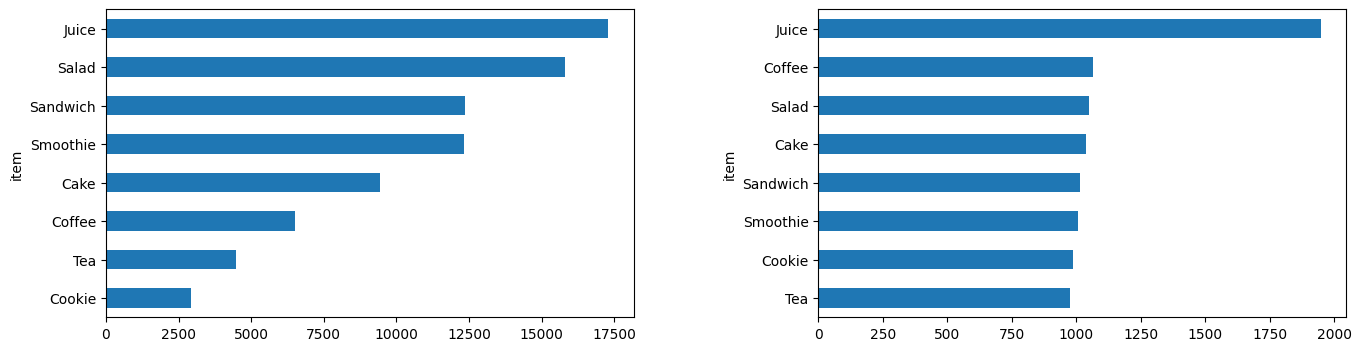

In [178]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('')
plt.subplots_adjust(hspace=0.45, wspace=0.35)

# total_spent per item
ax = axes[0]  # axes[0, 0]
df.groupby('item')['total_spent'].sum().sort_values().plot(kind='barh', ax=ax)

# count per item
ax = axes[1]  # axes[0, 1]
df['item'].value_counts().sort_values().plot(kind='barh', ax=ax)

plt.show()

In [166]:
df.groupby('item')['total_spent'].sum().sort_values().plot.barh

,total_spent
item,
Juice,17299.5
Salad,15805.0
Sandwich,12356.0
Smoothie,12340.0
Cake,9429.0
Coffee,6502.0
Tea,4462.5
Cookie,2946.0
